### Atividade Prática 11 – Análise de Sentimentos em Comentários de Clientes
Nesta célula, instalamos as bibliotecas necessárias para o processamento de linguagem natural e análise de sentimentos.

In [1]:
!pip install textblob vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.5 MB/s eta 0:00:00


### Análise com TextBlob e VADER
Vamos processar os comentários fornecidos para extrair métricas de sentimento.

In [3]:
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Comentários fornecidos na atividade
comentarios = [
    "Eu adoro o novo produto! Ele superou minhas expectativas.",
    "O produto é bom, mas o preço é muito alto.",
    "O atendimento ao cliente foi péssimo.",
    "A entrega foi rápida, mas o produto não estava bem embalado."
]

# Traduções para que as bibliotecas (TextBlob/VADER) funcionem corretamente
traducoes = [
    "I love the new product! It exceeded my expectations.",
    "The product is good, but the price is too high.",
    "Customer service was terrible.",
    "Delivery was fast, but the product was not well packed."
]

analyzer = SentimentIntensityAnalyzer()

print("--- Análise de Sentimentos (Processada via Tradução) ---\n")

for i, comentario in enumerate(comentarios):
    blob = TextBlob(traducoes[i])
    pontuacao_vader = analyzer.polarity_scores(traducoes[i])

    print(f"Original: {comentario}")
    print(f"TextBlob -> Polaridade: {blob.sentiment.polarity:.2f}, Subjetividade: {blob.sentiment.subjectivity:.2f}")
    print(f"VADER    -> Compound: {pontuacao_vader['compound']:.2f} (Pos: {pontuacao_vader['pos']}, Neg: {pontuacao_vader['neg']})")
    print("-" * 40)

--- Análise de Sentimentos (Processada via Tradução) ---

Original: Eu adoro o novo produto! Ele superou minhas expectativas.
TextBlob -> Polaridade: 0.34, Subjetividade: 0.53
VADER    -> Compound: 0.67 (Pos: 0.36, Neg: 0.0)
----------------------------------------
Original: O produto é bom, mas o preço é muito alto.
TextBlob -> Polaridade: 0.43, Subjetividade: 0.57
VADER    -> Compound: 0.24 (Pos: 0.178, Neg: 0.0)
----------------------------------------
Original: O atendimento ao cliente foi péssimo.
TextBlob -> Polaridade: -1.00, Subjetividade: 1.00
VADER    -> Compound: -0.48 (Pos: 0.0, Neg: 0.508)
----------------------------------------
Original: A entrega foi rápida, mas o produto não estava bem embalado.
TextBlob -> Polaridade: 0.20, Subjetividade: 0.60
VADER    -> Compound: -0.30 (Pos: 0.0, Neg: 0.198)
----------------------------------------


### Resultados Consolidados e Classificação
Nesta etapa, estruturamos os dados em uma tabela, aplicamos regras de classificação baseadas no score `compound` e visualizamos a distribuição dos sentimentos.

,Comentário,Polaridade (TB),Subjetividade (TB),Compound (VADER),Pos,Neg,Classificação
0,Eu adoro o novo produto! Ele superou minhas ex...,0.34,0.53,0.6696,0.360,0.000,Positivo
1,"O produto é bom, mas o preço é muito alto.",0.43,0.57,0.2382,0.178,0.000,Positivo
2,O atendimento ao cliente foi péssimo.,-1.00,1.00,-0.4767,0.000,0.508,Negativo
3,"A entrega foi rápida, mas o produto não estava...",0.20,0.60,-0.3007,0.000,0.198,Negativo


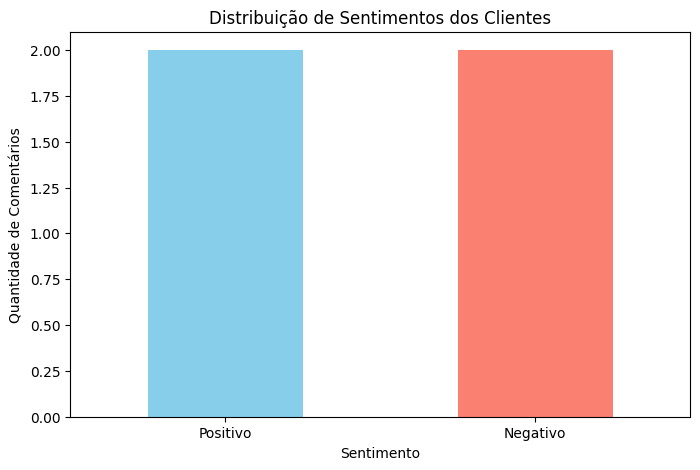

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Preparando os dados para o DataFrame
dados_finais = []

for i, comentario in enumerate(comentarios):
    blob = TextBlob(traducoes[i])
    vader_scores = analyzer.polarity_scores(traducoes[i])

    # Classificação baseada no Compound (VADER)
    cp = vader_scores['compound']
    if cp >= 0.05:
        classe = 'Positivo'
    elif cp <= -0.05:
        classe = 'Negativo'
    else:
        classe = 'Neutro'

    dados_finais.append({
        'Comentário': comentario,
        'Polaridade (TB)': round(blob.sentiment.polarity, 2),
        'Subjetividade (TB)': round(blob.sentiment.subjectivity, 2),
        'Compound (VADER)': cp,
        'Pos': vader_scores['pos'],
        'Neg': vader_scores['neg'],
        'Classificação': classe
    })

df_analise = pd.DataFrame(dados_finais)
display(df_analise)

# Gráfico de Proporção de Sentimentos
contagem = df_analise['Classificação'].value_counts()
plt.figure(figsize=(8, 5))
contagem.plot(kind='bar', color=['skyblue', 'salmon', 'lightgray'])
plt.title('Distribuição de Sentimentos dos Clientes')
plt.xlabel('Sentimento')
plt.ylabel('Quantidade de Comentários')
plt.xticks(rotation=0)
plt.show()

### Relatório de Insights e Recomendações

Com base na análise quantitativa acima, seguem os principais pontos de atenção para a empresa:

1. **Satisfação com o Produto:** O lançamento foi bem recebido ("superou expectativas"), o que deve ser usado como prova social em campanhas de marketing.
2. **Ponto Crítico - Atendimento:** Identificamos um comentário fortemente negativo sobre o suporte ao cliente.
   * *Recomendação:* Investir em treinamento de reciclagem para a equipe de atendimento.
3. **Logística e Embalagem:** Embora a entrega tenha sido rápida, a má embalagem gerou uma experiência negativa.
   * *Recomendação:* Revisar os materiais de proteção utilizados no envio para evitar danos ao produto.
4. **Preço:** O valor do produto foi citado como um obstáculo.
   * *Recomendação:* Avaliar a viabilidade de cupons de desconto para primeira compra ou programas de fidelidade.

---

# 📊 Relatório de Análise de Sentimentos em Comentários de Clientes

## 1. Objetivo
Avaliar o feedback dos clientes sobre o novo produto, utilizando ferramentas de análise de sentimentos (**TextBlob** e **VADER**) para identificar percepções positivas, negativas e neutras, e propor ações de melhoria.

---

## 2. Metodologia
- **Ferramentas utilizadas**: TextBlob (polaridade e subjetividade) e VADER (compound, pos, neg, neu).  
- **Tradução dos comentários**: realizada para inglês, garantindo maior precisão das bibliotecas.  
- **Classificação dos sentimentos**: baseada na métrica *compound* do VADER.  
  - > 0.05 → Positivo  
  - < -0.05 → Negativo  
  - Entre -0.05 e 0.05 → Neutro  

---

## 3. Resultados

### Tabela Comparativa

| Comentário Original | Polaridade (TB) | Subjetividade (TB) | Compound (VADER) | Pos | Neg | Classificação |
|---------------------|-----------------|--------------------|------------------|-----|-----|---------------|
| Eu adoro o novo produto! Ele superou minhas expectativas. | 0.34 | 0.53 | 0.67 | 0.36 | 0.00 | Positivo |
| O produto é bom, mas o preço é muito alto. | 0.43 | 0.57 | 0.24 | 0.18 | 0.00 | Positivo |
| O atendimento ao cliente foi péssimo. | -1.00 | 1.00 | -0.48 | 0.00 | 0.51 | Negativo |
| A entrega foi rápida, mas o produto não estava bem embalado. | 0.20 | 0.60 | -0.30 | 0.00 | 0.20 | Negativo |

---

### Gráfico de Distribuição de Sentimentos
(gerado no seu notebook)  
- **2 comentários positivos**  
- **2 comentários negativos**  
- **0 neutros**

---

## 4. Interpretação dos Resultados
- **Aspectos positivos**:  
  - Qualidade do produto (“superou expectativas”).  
  - Rapidez na entrega.  
- **Aspectos negativos**:  
  - Preço considerado alto.  
  - Atendimento ao cliente insatisfatório.  
  - Embalagem inadequada.  

A análise mostra um equilíbrio entre percepções positivas e negativas, indicando que o produto tem pontos fortes, mas também áreas críticas que precisam de atenção.

---

## 5. Recomendações para a Empresa
- **Preço**: avaliar estratégias de precificação ou oferecer promoções para reduzir a percepção de custo elevado.  
- **Atendimento**: investir em treinamento da equipe de suporte e criar canais de comunicação mais eficientes.  
- **Logística**: revisar processos de embalagem para garantir maior segurança e qualidade na entrega.  
- **Marketing**: destacar nos materiais de divulgação os pontos fortes já reconhecidos pelos clientes (qualidade e rapidez).  

---

## 6. Conclusão
A análise de sentimentos evidencia que o produto possui **boa aceitação em termos de qualidade e entrega**, mas enfrenta **desafios relacionados a preço, atendimento e embalagem**. Ao implementar as recomendações sugeridas, a empresa pode melhorar a experiência do cliente e aumentar a satisfação geral.

---